In [2]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(NOT\s+\w+:\w+:\S+|\w+:\w+:\S+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    
    return unit_concepts, raw_concepts
 


In [8]:
!python -m spacy download en_core_web_sm
import spacy
import nltk
from nltk.corpus import wordnet as wn
from nltk import pos_tag
from collections import defaultdict
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")
SUPERSENSE_TO_CATEGORY = {
    # Verbs
    "verb.motion": "actions",
    "verb.contact": "actions",
    "verb.consumption": "actions",
    "verb.stative": "states",
    "verb.perception": "states",

    # Nouns
    "noun.location": "locations",
    "noun.person": "object",
    "noun.animal": "object",
    "noun.artifact": "object",
    "noun.object": "object",
    "noun.food": "object",
    "noun.substance": "object",

    # Adjectives
    "adj.all": "adjectives",
    "adj.pert": "adjectives"
}

def to_wn_pos(word):
    doc = nlp(word)
    for token in doc:
        
        if 'NN' in token.tag_ :
            return wn.NOUN
        elif 'VB' in token.tag_  :
            return wn.VERB
        elif 'JJ' in token.tag_:
            return wn.ADJ
        elif 'RB' in token.tag_:
            return wn.ADV
    return None

def get_supersense(word, pos):
    synsets = wn.synsets(word, pos=pos)
    if not synsets:
        return None
    return synsets[0].lexname()

def is_pos_ambiguous(word):
    pos_list = []
    for pos in [wn.NOUN, wn.VERB, wn.ADJ, wn.ADV]:
        if wn.synsets(word, pos=pos):
            pos_list.append(pos)
    return len(pos_list) > 1, pos_list

def categorize_words(words):
    words =list([word.split(":")[-1] for word in words])
    categories = defaultdict(list)



    for word in words:
        if word == 'AND' or word=='OR': continue
        wn_pos = to_wn_pos(word)

        if wn_pos is None:
            categories["function_words"].append(word)
            continue

        supersense = get_supersense(word, wn_pos)

        if supersense is None:
            categories["POS"].append(word)
            continue

        category = SUPERSENSE_TO_CATEGORY.get(supersense, "other")
        categories[category].append(word)

    return dict(categories)

_, rawc1 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/Expls/0.25267370011269075%Pruned/Cluster1IOUS1024N.csv')
_, rawc2 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/Expls/0.25267370011269075%Pruned/Cluster2IOUS1024N.csv')
_, rawc3 = load_csv_data(filepath='/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/Expls/0.25267370011269075%Pruned/Cluster3IOUS1024N.csv')
print("Loaded CSV Data")
categsc1=categorize_words(rawc1)
categsc2=categorize_words(rawc2)
categsc3=categorize_words(rawc3)

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Loaded CSV Data


In [43]:
def count(concepts, token, remove_not=False):
    inc = 0
    raw = []
    for i in concepts:
        if 'AND' in i or 'OR' in i:
            assert False
        if remove_not:
            
            if token in i and 'NOT' not in i:
                
                inc += 1
                raw.append(i)
        else:
            if token in i:
                inc += 1
                raw.append(i)
        
    return raw, inc


In [221]:
pd.DataFrame(cluster_results).to_csv("/workspace/CCE_NLI/BERT/exp/CoFi/Run0.25_5/concept_count_without_redundnacy.csv")

Unique concept at cluster 1 for lottery_ticket 0.0 = 10.889748549323018
Unique concept at cluster 2 for lottery_ticket 0.0 = 7.2265625
Unique concept at cluster 3 for lottery_ticket 0.0 = 11.434689507494646
GLOBAL 0.0%Pruned lottery_ticket 6.223262032085562
Unique concept at cluster 1 for lottery_ticket 25.0 = 10.95703125
Unique concept at cluster 2 for lottery_ticket 25.0 = 7.79296875
Unique concept at cluster 3 for lottery_ticket 25.0 = 11.146496815286625
GLOBAL 25.0%Pruned lottery_ticket 6.260869565217392
Unique concept at cluster 1 for lottery_ticket 43.75 = 11.23046875
Unique concept at cluster 2 for lottery_ticket 43.75 = 7.63671875
Unique concept at cluster 3 for lottery_ticket 43.75 = 11.446540880503145
GLOBAL 43.75%Pruned lottery_ticket 6.295802798134577
Unique concept at cluster 1 for lottery_ticket 57.812 = 11.11328125
Unique concept at cluster 2 for lottery_ticket 57.812 = 8.02734375
Unique concept at cluster 3 for lottery_ticket 57.812 = 11.50460593654043
GLOBAL 57.812%Pru

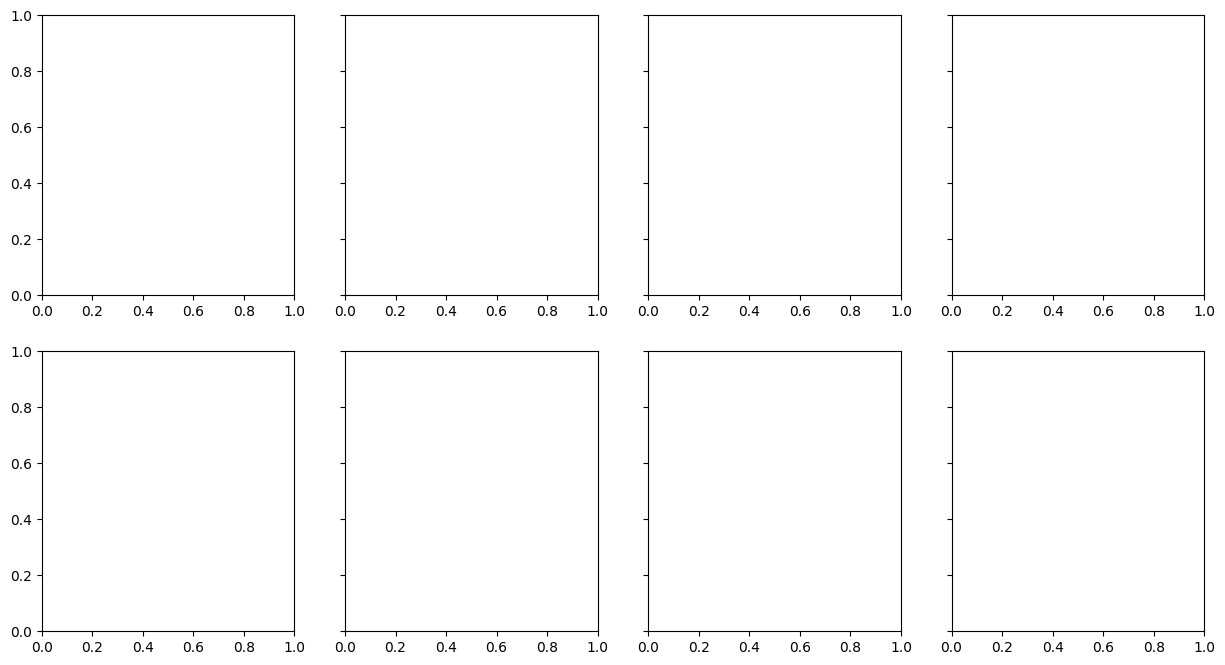

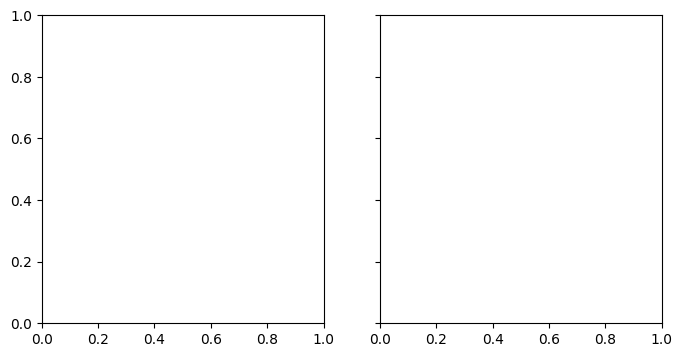

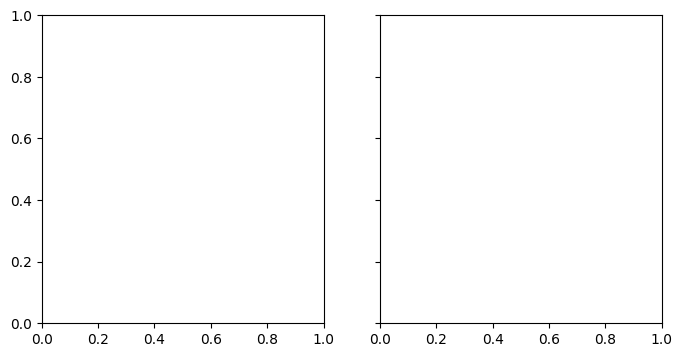

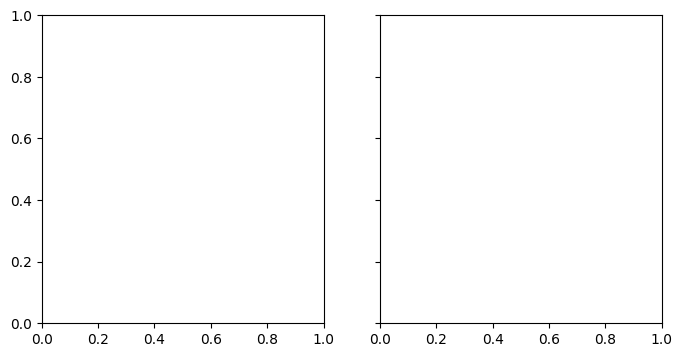

In [93]:
#unique concept dist

methods = ['lottery_ticket', 'CoFi']
fig_concept_counts, axes_concept_counts = plt.subplots(2, 4, figsize=(15, 8), sharey=True)
fig_accuracies, axes_accuracies = plt.subplots(1,2, figsize=(8, 4), sharey=True)
fig_totalConcepts, axes_totalConcepts = plt.subplots(1,2, figsize=(8, 4), sharey=True)
fig_explNeurons, axes_explNeurons = plt.subplots(1,2, figsize=(8, 4), sharey=True)

for row, m in enumerate(methods):
    # Collect filepaths for this method
    filepaths = [
        f'/workspace/CCE_NLI/BERT/exp/{m}/Run0.25_5/Expls/', 
        f'/workspace/CCE_NLI/BERT/exp/{m}/Run0.25_6/Expls/',
        f'/workspace/CCE_NLI/BERT/exp/{m}/Run0.25_7/Expls/',
    ]
    acc_filepaths = [
        f"/workspace/CCE_NLI/BERT/models/{m}/Run0.25_5/accuracy.csv",
        f"/workspace/CCE_NLI/BERT/models/{m}/Run0.25_6/accuracy.csv",
        f"/workspace/CCE_NLI/BERT/models/{m}/Run0.25_7/accuracy.csv",
    ]
    
    # Filter to existing paths
    existing_filepaths = [fp for fp, acc_fp in zip(filepaths, acc_filepaths) 
                          if os.path.exists(fp)]
    
    if not existing_filepaths:
        print(f"Skipping method {m}: no valid filepaths found")
        continue
    
    # Accumulate results across files
    cluster_results_accumulator = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: {'sum': 0, 'count': 0})))
    accuracy_accumulator = defaultdict(lambda: {'sum': 0, 'count': 0})
    
    for i, filepath in enumerate(existing_filepaths):
        accs=None
        all_pres = []
        all_hyps = []
        all_nots = []
    
        if os.path.exists(acc_filepaths[i]):
            accs = pd.read_csv(acc_filepaths[i])
           
            
        
        for i, sparsity_explanation_folder in enumerate(sorted(os.listdir(filepath))):
            if '.ipynb' in sparsity_explanation_folder:continue
            sparsity_level = sparsity_explanation_folder.split("%")[0]
            total_unique_cp=set()
            expl_neurons=set()
            total_including_repeats= []
            total_nots=[]
            unique_nots=set()
            # Accumulate accuracy
            if accs is not None:
                accuracy_accumulator[sparsity_level]['sum'] += accs.iloc[i]['accs']
                accuracy_accumulator[sparsity_level]['count'] += 1
            
            for cluster in range(1, 4):
                skip=False
                try:
                    if sparsity_level=='0.0':
                        filepath_=f'/workspace/CCE_NLI/BERT/exp/{m}/Run0.25_5/Expls/'
                    else:
                        filepath_=filepath
                    filepath_main=filepath_
                    cluster_explanations_per_unit, cluster_explanations_all = load_csv_data(
                        os.path.join(filepath_main, sparsity_explanation_folder, f'Cluster{cluster}IOUS1024N.csv')
                    )
                    cluster_explanations_all_set = set(cluster_explanations_all)
                except:
                    print("Skipping ", os.path.join(filepath_main, sparsity_explanation_folder, f'Cluster{cluster}IOUS1024N.csv'))
                    skip=True
                    continue
                pre_cp, pre_count_val = count(cluster_explanations_all_set, 'pre', True)
                hyp_cp, hyp_count_val = count(cluster_explanations_all_set, 'hyp', True)
                not_cp_uniquenots, not_countunique_val = count(cluster_explanations_all_set, "NOT")
                
                
                not_nonuniquecp, not_count_nonunique_val = count(cluster_explanations_all, "NOT")
                print(f"Unique concept at cluster {cluster} for {m} {sparsity_level} = {100*len(cluster_explanations_all_set)/len(cluster_explanations_all)}")
                total_unique_cp = total_unique_cp.union(cluster_explanations_all_set)
                
                total_including_repeats.extend(cluster_explanations_all)
                expl_neurons = expl_neurons.union(set(cluster_explanations_per_unit.keys()))
                total_nots.extend(not_nonuniquecp)
                unique_nots = unique_nots.union(not_cp_uniquenots)
                
                # Accumulate metrics
                cluster_results_accumulator[sparsity_level][cluster]['pre']['sum'] += pre_count_val
                cluster_results_accumulator[sparsity_level][cluster]['pre']['count'] += 1
                
                cluster_results_accumulator[sparsity_level][cluster]['hyp']['sum'] += hyp_count_val
                cluster_results_accumulator[sparsity_level][cluster]['hyp']['count'] += 1
                
                cluster_results_accumulator[sparsity_level][cluster]['not']['sum'] += not_count_val
                cluster_results_accumulator[sparsity_level][cluster]['not']['count'] += 1
                
                cluster_results_accumulator[sparsity_level][cluster]['total']['sum'] += len(cluster_explanations_all) - not_count_nonunique_val
                cluster_results_accumulator[sparsity_level][cluster]['total']['count'] += 1
                
                cluster_results_accumulator[sparsity_level][cluster]['positive_unique']['sum'] += len(cluster_explanations_all_set) - not_countunique_val
                cluster_results_accumulator[sparsity_level][cluster]['positive_unique']['count'] += 1
                
                cluster_results_accumulator[sparsity_level][cluster]['num_explainable_neurons']['sum'] += len(cluster_explanations_per_unit)
                cluster_results_accumulator[sparsity_level][cluster]['num_explainable_neurons']['count'] += 1
                
                all_pres.extend(pre_cp)
                all_hyps.extend(hyp_cp)
                all_nots.extend(not_uniquecp)
            if len(total_including_repeats)==0:
                print(m,sparsity_explanation_folder, os.path.join(filepath_main, sparsity_explanation_folder, f'Cluster{cluster}IOUS1024N.csv'))
            print("GLOBAL", sparsity_explanation_folder, m, 100*len(total_unique_cp)/len(total_including_repeats))
            if not skip:
                cluster = 4
                cluster_results_accumulator[sparsity_level][cluster]['global_pre']['sum'] += len(set(all_pres))
                cluster_results_accumulator[sparsity_level][cluster]['global_pre']['count'] += 1

                cluster_results_accumulator[sparsity_level][cluster]['global_hyp']['sum'] += len(set(hyp_cp))
                cluster_results_accumulator[sparsity_level][cluster]['global_hyp']['count'] += 1

                cluster_results_accumulator[sparsity_level][cluster]['global_unique_nots']['sum'] += len(set(all_nots))
                cluster_results_accumulator[sparsity_level][cluster]['global_unique_nots']['count'] += 1


                cluster_results_accumulator[sparsity_level][cluster]['total_positive_unique']['sum'] += len(total_unique_cp) - len(set(unique_nots))
                cluster_results_accumulator[sparsity_level][cluster]['total_positive_unique']['count'] += 1

                cluster_results_accumulator[sparsity_level][cluster]['total']['sum'] += len(total_including_repeats) - len(total_nots)
                cluster_results_accumulator[sparsity_level][cluster]['total']['count'] += 1

                cluster_results_accumulator[sparsity_level][cluster]['num_explainable_neurons']['sum'] += len(expl_neurons)
                cluster_results_accumulator[sparsity_level][cluster]['num_explainable_neurons']['count'] += 1
            
    
    # Compute averages
    cluster_results = defaultdict(lambda: defaultdict(dict))
    for sparsity_level in cluster_results_accumulator:
        for cluster in cluster_results_accumulator[sparsity_level]:
            for metric in cluster_results_accumulator[sparsity_level][cluster]:
                total = cluster_results_accumulator[sparsity_level][cluster][metric]['sum']
                num_samples = cluster_results_accumulator[sparsity_level][cluster][metric]['count']
                
                cluster_results[sparsity_level][cluster][metric] = total / num_samples if num_samples > 0 else 0
    
    # Average accuracies
    if accuracy_accumulator is not None:
        pruning = sorted(accuracy_accumulator.keys())
        accuracies = [accuracy_accumulator[p]['sum'] / accuracy_accumulator[p]['count'] 
                      if accuracy_accumulator[p]['count'] > 0 else 0 
                      for p in pruning]

    # Prepare data for plotting
    clusters = defaultdict(lambda: defaultdict(list))
    totals = defaultdict(lambda: defaultdict(list))
    expl_neurons = defaultdict(lambda: defaultdict(list))
    
    for s in sorted(cluster_results.keys()):
        for c, v in cluster_results[s].items():
            if c==4: 
                clusters[c]['global_pre'].append(v['global_pre'])
                clusters[c]['global_hyp'].append(v['global_hyp'])
                clusters[c]['global_unique_nots'].append(v['global_unique_nots'])
                clusters[c]['positive_unique'].append(v['total_positive_unique'])
                totals[c]['total'].append(v['total'])
            else:
                clusters[c]['pre'].append(v['pre'])
                clusters[c]['hyp'].append(v['hyp'])
                clusters[c]['not'].append(v['not'])
                clusters[c]['positive_unique'].append(v['positive_unique'])
                totals[c]['total'].append(v['total'])
        
            if c == 1:
                baseline = v['num_explainable_neurons']
            expl_neurons[c]['num_explainable_neurons'].append(v['num_explainable_neurons']/baseline)
       
       
            
            
    
    # --- compute global y-axis limits ---
    '''all_vals = []
    for c in clusters.values():
        for v in c.values():
            all_vals.extend(v)
    
    ymin, ymax = min(all_vals) - 200, max(all_vals) + 200
    
    # --- plot ---
    
    for col, name in enumerate(sorted(clusters.keys())):
        ax = axes_concept_counts[row, col]
        
        for key, vals in clusters[name].items():
            if name==4:
                print(pruning, vals)
            ax.plot(pruning, vals, marker='o', label=key)
        
        ax.set_title(f"METHOD {m} Cluster {name}")
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Pruning Fraction")
        ax.tick_params(axis='x', labelrotation=45)
        if col == 0:
            ax.set_ylabel("Count")
        ax.grid()
    fig_concept_counts.subplots_adjust(hspace=0.4)
    
    if accuracies is not None:
        # Plot accuracies
        ax = axes_accuracies[row]
        ax.set_title(f"METHOD {m} Accuracies")
        ax.plot(pruning, accuracies, marker='o')
        ax.set_xlabel("Pruning Fraction")
        ax.tick_params(axis='x', labelrotation=45)
        ax.set_ylabel("Percent")
        ax.grid()
    
    # Plot total concepts
    ax = axes_totalConcepts[row]
    for i in range(1, 5):
        if i ==4:
            label = 'global'
        else:
            label = i

        ax.plot(pruning, totals[i]['total'], label=f"Cluster {label}", marker='o')
    ax.set_title(f"METHOD {m} Positive Total")
    ax.set_xlabel("Pruning Fraction")
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel("Count")
    ax.grid()
    ax.legend()
    
    ax = axes_explNeurons[row]
    for i in range(1, 5):
        ax.plot(pruning, expl_neurons[i]['num_explainable_neurons'], label=f"Cluster {i}", marker='o')
    ax.set_title(f"METHOD {m} Expl Neurons")
    ax.set_xlabel("Pruning Fraction")
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel("Percent")
    ax.grid()
    ax.legend()
    
    

# Add legend to concept counts figure
handles, labels = axes_concept_counts[0, 0].get_legend_handles_labels()
fig_concept_counts.legend(handles, labels, loc="upper center", ncol=4)

plt.tight_layout()
plt.show()'''

In [141]:

import nltk
from nltk import word_tokenize, pos_tag
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
# Ensure necessary NLTK data is downloaded (run once)

import pandas as pd
from collections import defaultdict
counts = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
for method in ['lottery_ticket', 'CoFi']:
    model='BERT'
    file='Run0.25_5'
    root = f"/workspace/CCE_NLI/{model}/exp/{method}/{file}/Expls"
    
    conceptslist = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
    df=pd.read_csv(f'/workspace/CCE_NLI/BERT/exp/csv_output/{method}_global_all_sparsities.csv')
    cluster='all'
    for col in df.columns:
        if 'count' in col: continue
        sparsity = float(col.split("concept")[-1].split("%")[0])
        all_concepts = [concept for concept in df[col] if isinstance(concept,str)]



        words =list([word.split(":")[-1] for word in all_concepts if word not in ['AND', 'OR'] and 'tag:' not in word and 'oth:overlap' not in word and 'NOT' not in word])


        # 1. Tokenize the text into words
        tokens = word_tokenize(" ".join(words))

        # 2. Perform POS tagging
        # The result is a list of tuples: [('word', 'POS_tag'), ...]
        tagged_words = pos_tag(tokens)

        # 3. Filter for nouns and verbs
        nouns = [word for word, tag in tagged_words if tag.startswith('NN')]
       
        verbs = [word for word, tag in tagged_words if tag.startswith('VB')]
        adj = [word for word, tag in tagged_words if tag.startswith('JJ')]

        counts[method][sparsity][f'Cluster{cluster}']['Nouns'] = len(nouns)
        print(counts.keys())
        counts[method][sparsity][f'Cluster{cluster}']['Verbs'] = len(verbs)
        counts[method][sparsity][f'Cluster{cluster}']['Adj'] = len(adj)

        conceptslist[method][sparsity][f'Cluster{cluster}']['Nouns'] = nouns
        conceptslist[method][sparsity][f'Cluster{cluster}']['Verbs'] = verbs
        conceptslist[method][sparsity][f'Cluster{cluster}']['Adj'] = adj
pd.DataFrame(counts)
                                    
                                 



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket'])
dict_keys(['lottery_ticket', 'CoFi'])
dict_keys(['lottery_ticket', 'CoFi'])
dict_keys(['lottery_ticket', 'CoFi'])
dict_keys(['lottery_ticket', 'CoFi'])
dict_keys(['lottery_ticket', 'CoFi'])
dict_keys(['lottery_ticket', 'CoFi'])


,lottery_ticket,CoFi
0.000000,"{'Clusterall': {'Nouns': 200, 'Verbs': 97, 'Ad...","{'Clusterall': {'Nouns': 219, 'Verbs': 102, 'A..."
25.000000,"{'Clusterall': {'Nouns': 209, 'Verbs': 97, 'Ad...",NaN
43.750000,"{'Clusterall': {'Nouns': 220, 'Verbs': 104, 'A...",NaN
57.812000,"{'Clusterall': {'Nouns': 224, 'Verbs': 106, 'A...",NaN
68.359000,"{'Clusterall': {'Nouns': 224, 'Verbs': 103, 'A...",NaN
76.270000,"{'Clusterall': {'Nouns': 227, 'Verbs': 98, 'Ad...",NaN
0.252674,NaN,"{'Clusterall': {'Nouns': 235, 'Verbs': 104, 'A..."
0.444328,NaN,"{'Clusterall': {'Nouns': 235, 'Verbs': 112, 'A..."
0.582675,NaN,"{'Clusterall': {'Nouns': 222, 'Verbs': 102, 'A..."
0.684185,NaN,"{'Clusterall': {'Nouns': 220, 'Verbs': 106, 'A..."


NameError: name 'counts' is not defined

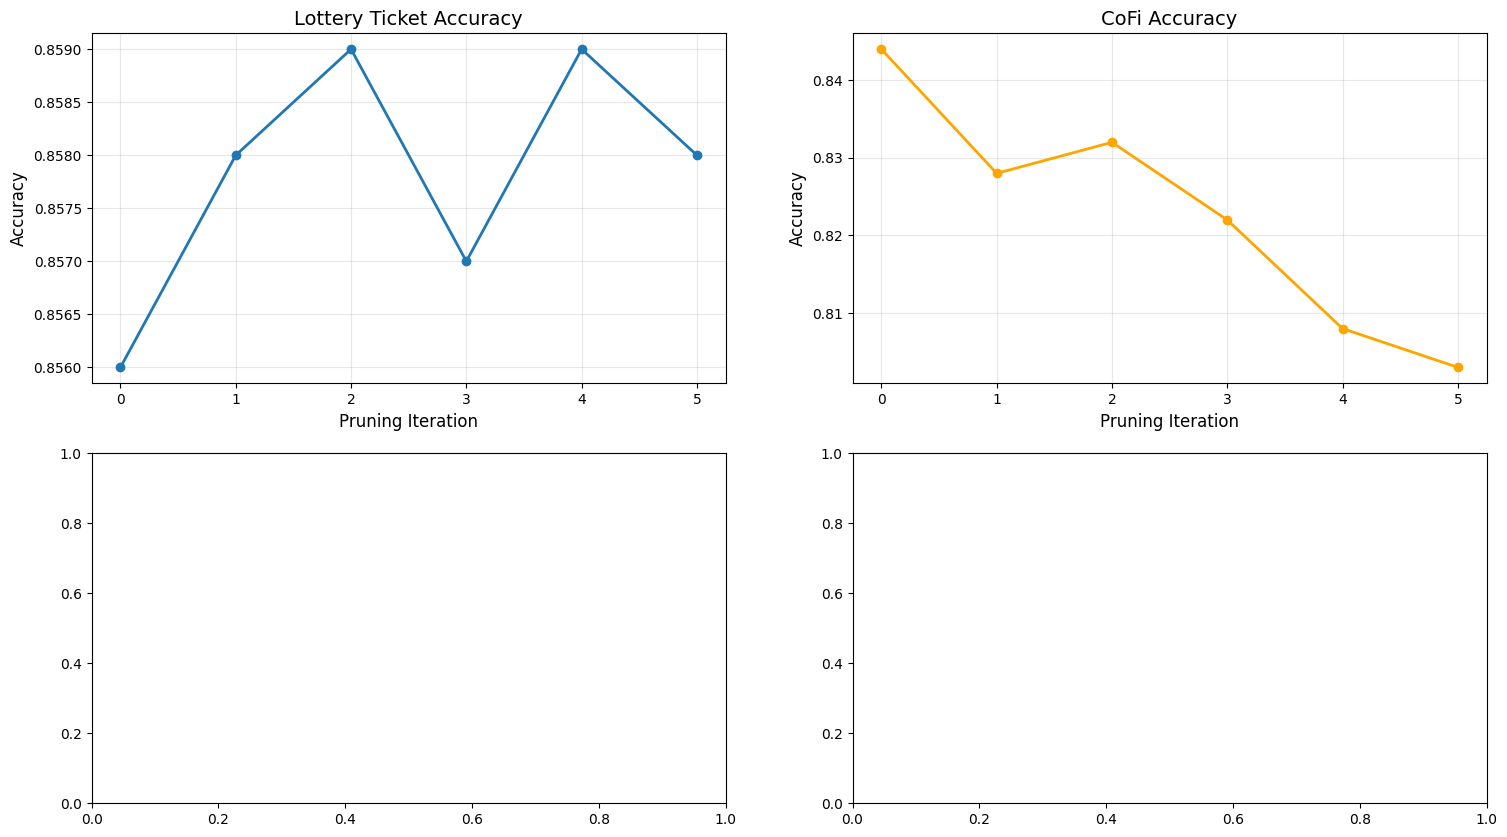

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Lottery Ticket Accuracies
acc_df_lottery = pd.read_csv('/workspace/CCE_NLI/BERT/models/lottery_ticket/Run0.25_5/accuracy.csv')
ax1 = axes[0, 0]
ax1.plot(acc_df_lottery['Unnamed: 0'], acc_df_lottery['accs'], marker='o', linewidth=2)
ax1.set_xlabel('Pruning Iteration', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Lottery Ticket Accuracy', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(acc_df_lottery['Unnamed: 0'].values)  # Use .values

# Plot 2: CoFi Accuracies
acc_df_cofi = pd.read_csv('/workspace/CCE_NLI/BERT/models/CoFi/Run0.25_5/accuracy.csv')
ax2 = axes[0, 1]
ax2.plot(acc_df_cofi['Unnamed: 0'], acc_df_cofi['accs'], marker='o', linewidth=2, color='orange')
ax2.set_xlabel('Pruning Iteration', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('CoFi Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([int(i) for i in acc_df_cofi['Unnamed: 0'].values])  # Use .values

# Hide third plot in first row

# Plot POS counts for both methods

for idx, method in enumerate(['lottery_ticket', 'CoFi']):
    ax = axes[1, idx]

    # Extract data from counts dictionary
    sparsity_levels = sorted(counts[method].keys())

    clusters = sorted([k for k in counts[method][sparsity_levels[0]].keys() if 'Cluster' in k])

    # Plot each POS type
    for pos_type in ['Nouns', 'Verbs', 'Adj']:
        values = []
        print(sparsity_levels)
        for sparsity in sparsity_levels:
            cluster_vals = [int(counts[method][sparsity][cluster].get(pos_type, 0))  for cluster in clusters]
            values.append(sum(cluster_vals))  # Sum across clusters

        ax.plot(range(len(sparsity_levels)), values, marker='o', label=pos_type, linewidth=2)
    print(values)
    ax.set_xlabel('Sparsity Level', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{method} POS Counts', fontsize=14)
    ax.set_xticks(range(len(sparsity_levels)))
    # Convert sparsity levels to strings for labels

    ax.set_xticklabels([s for s in sparsity_levels], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)

print("DONE")



In [34]:
import os
import csv
from collections import Counter, defaultdict

methods = ['lottery_ticket', 'CoFi']
global_red = defaultdict(list)
local_avg_reundnacy_at_sparsity_methods = []

output_dir = '/workspace/CCE_NLI/BERT/exp/csv_output'
os.makedirs(output_dir, exist_ok=True)

for method in methods:
    root = f'/workspace/CCE_NLI/BERT/exp/{method}/Run0.25_5/Expls'
    sparsities = os.listdir(root)
    
    local_avg_reundnacy_at_sparsity = []
    global_reundnacy_at_sparsity = []
    
    for sparsity in sparsities:
        concepts_redundnacy_at_cluster = []  # reset per sparsity
        global_concepts = []
        for cluster in range(1,4):
            per_unit, all_concepts = load_csv_data(os.path.join(root, sparsity, f"Cluster{cluster}IOUS1024N.csv"))
            all_concepts = [i for i in all_concepts if 'NOT ' not in i]
            counter = Counter(all_concepts)
            concepts_redundnacy_at_cluster.append(counter)
            global_concepts.extend(all_concepts)
        
        local_avg_reundnacy_at_sparsity.append(concepts_redundnacy_at_cluster)
        global_counter = Counter(global_concepts)
        global_reundnacy_at_sparsity.append(global_counter)
    
    global_red[method] = global_reundnacy_at_sparsity
    local_avg_reundnacy_at_sparsity_methods.append(local_avg_reundnacy_at_sparsity)

import os
import csv
from collections import Counter

output_dir = '/workspace/CCE_NLI/BERT/exp/csv_output'
os.makedirs(output_dir, exist_ok=True)

methods = ['lottery_ticket', 'CoFi']

for method_idx, method in enumerate(methods):
    local_data = local_avg_reundnacy_at_sparsity_methods[method_idx]  # list of sparsities, each has 3 cluster counters
    root = f'/workspace/CCE_NLI/BERT/exp/{method}/Run0.25_5/Expls'
    sparsities = sorted(os.listdir(root), key=lambda x: float(x.split("%")[0]))  # sort sparsity numerically

    num_clusters = 3
    for cluster_idx in range(num_clusters):
        # Collect concept counts for this cluster across all sparsities
        cluster_sparsity_counters = [local_data[s_idx][cluster_idx] for s_idx in range(len(sparsities))]

        # Create a **set of all concepts across all sparsities**
        all_concepts = set()
        for counter in cluster_sparsity_counters:
            all_concepts.update(counter.keys())

        # Sort concepts by count in the first sparsity (0% sparsity)
        sorted_concepts = sorted(all_concepts, key=lambda c: cluster_sparsity_counters[0].get(c, 0), reverse=True)

        # Write CSV for this cluster
        csv_name = f"{method}_cluster{cluster_idx+1}.csv"
        csv_path = os.path.join(output_dir, csv_name)
        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)

            # Header
            header = []
            for s in sparsities:
                header.extend([f"concept{s}", f"count{s}"])
            writer.writerow(header)

            # Rows
            for concept in sorted_concepts:
                row = []
                for counter in cluster_sparsity_counters:
                    row.append(concept if concept in counter else '')
                    row.append(counter.get(concept, 0))
                writer.writerow(row)

import os
import csv
from collections import Counter

output_dir = '/workspace/CCE_NLI/BERT/exp/csv_output'
os.makedirs(output_dir, exist_ok=True)

methods = ['lottery_ticket', 'CoFi']

for method in methods:
    global_data = global_red[method]  # list of Counters at each sparsity
    root = f'/workspace/CCE_NLI/BERT/exp/{method}/Run0.25_5/Expls'
    sparsities = sorted(os.listdir(root), key=lambda x: float(x.split("%")[0]))  # sort sparsities numerically

    # Build the set of all concepts across all sparsities
    all_concepts = set()
    for counter in global_data:
        all_concepts.update(counter.keys())

    # Sort concepts by count in the first sparsity (0%) descending
    sorted_concepts = sorted(all_concepts, key=lambda c: global_data[0].get(c, 0), reverse=True)

    # Write one CSV per method
    csv_name = f"{method}_global_all_sparsities.csv"
    csv_path = os.path.join(output_dir, csv_name)
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)

        # Header: concept0, count0, concept25, count25, ...
        header = []
        for s in sparsities:
            header.extend([f"concept{s}", f"count{s}"])
        writer.writerow(header)

        # Write rows
        for concept in sorted_concepts:
            row = []
            for counter in global_data:
                row.append(concept if concept in counter else '')
                row.append(counter.get(concept, 0))
            writer.writerow(row)


[Counter({'pre:tag:nn': 456,
          'NOT hyp:tok:outside': 204,
          'hyp:tag:nn': 179,
          'oth:overlap:overlap25': 140,
          'NOT hyp:tok:outdoors': 111,
          'NOT hyp:tok:sleeping': 110,
          'hyp:tag:dt': 106,
          'pre:tag:jj': 101,
          'NOT oth:overlap:overlap50': 97,
          'pre:tag:.': 79,
          'pre:tag:dt': 76,
          'hyp:tag:vbg': 73,
          'NOT oth:overlap:overlap75': 73,
          'NOT hyp:tok:for': 73,
          'pre:tag:in': 67,
          'hyp:tag:in': 58,
          'NOT pre:tok:walking': 51,
          'NOT pre:tok:dog': 50,
          'NOT hyp:tok:wearing': 49,
          'NOT hyp:tok:tall': 49,
          'pre:tok:man': 47,
          'oth:overlap:overlap50': 46,
          'NOT hyp:tok:inside': 45,
          'NOT hyp:tok:nobody': 44,
          'NOT pre:tok:girl': 42,
          'NOT hyp:tok:eating': 40,
          'pre:tok:woman': 37,
          'NOT hyp:tok:walking': 36,
          'NOT hyp:tok:people': 33,
          'NOT

**OLD**

In [58]:
import spacy
nlp = spacy.load("en_core_web_sm")  # large model, trained on huge corpus

doc = nlp("sand")
for token in doc:
    print(token.text, token.pos_, token.tag_)


sand VERB VB


In [61]:
import nltk
from nltk.corpus import wordnet as wn
from collections import defaultdict

# Ensure resources are downloaded
nltk.download("wordnet")
nltk.download("omw-1.4")

# Mapping WordNet lexnames (supersenses) to semantic categories
SUPERSENSE_TO_CATEGORY = {
    # Verbs
    "verb.motion": "actions",
    "verb.contact": "actions",
    "verb.consumption": "actions",
    "verb.stative": "states",
    "verb.perception": "states",

    # Nouns
    "noun.location": "locations",
    "noun.person": "entities",
    "noun.animal": "entities",
    "noun.artifact": "entities",
    "noun.object": "entities",
    "noun.food": "entities",
    "noun.substance": "entities",

    # Adjectives
    "adj.all": "attributes",
    "adj.pert": "attributes"
}

def get_word_pos_set(word):
    """Return all POS in WordNet for this word"""
    pos_set = set()
    for pos in [wn.NOUN, wn.VERB, wn.ADJ, wn.ADV]:
        if wn.synsets(word, pos=pos):
            pos_set.add(pos)
    return pos_set

def categorize_word(word):
    pos_set = get_word_pos_set(word)
    
    # No synsets at all → abstract
    if not pos_set:
        return "abstract"
    
    # Multiple POS → ambiguous → abstract
    if len(pos_set) > 1:
        for i in range(len(pos_set)):
            pos_set.update(get_word_pos_set(word))
        print(Counter(pos_set))
        
    
    # Single POS → pick dominant sense (first synset)
    pos = pos_set.pop()
    synset = wn.synsets(word, pos=pos)[0]
    lexname = synset.lexname()
    return SUPERSENSE_TO_CATEGORY.get(lexname, "abstract")

def categorize_words(words):
    categories = defaultdict(list)
    for word in words:
        cat = categorize_word(word.lower())
        categories[cat].append(word)
    return dict(categories)

# Example usage
words = [
    "running", "swimming", "sleeping", "asleep",
    "inside", "outside", "outdoors",
    "person", "people", "dog", "cat",
    "tall", "blue",
    "to", "for", "they", "is",
    "horse", "sand"
]

result = categorize_words(words)
print(result)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


NameError: name 'Counter' is not defined